# Capstone Project I: Mutual Fund Analytics
## Interactive Exploratory Data Analysis & Financial Metrics (2022 - 2026)

This notebook contains the comprehensive, publication-quality exploratory data analysis (EDA) for **Capstone Project I - Mutual Fund Analytics**. The study covers daily Net Asset Values (NAVs) for 40 schemes, yearly Assets Under Management (AUM), monthly SIP inflows, investor demographics, and sector holdings.

### Notebook Structure
- **Section 1: Data Ingestion & Overview**
- **Section 2: NAV Trajectory & Market Regimes (Interactive Plotly)**
- **Section 3: AUM Growth & Market Share**
- **Section 4: Retail Investment Momentum (Interactive Plotly)**
- **Section 5: Inflow Dynamics & Heatmap**
- **Section 6: Investor Demographics & Ticket Sizes**
- **Section 7: Geographic Demographics & State-wise SIP**
- **Section 8: Folio Penetration Growth**
- **Section 9: Portfolio Sector & Stock Allocations**
- **Section 10: Risk-Return Optimization & Volatility**

---


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

# Setup styles
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (11, 5.5)
plt.rcParams['figure.dpi'] = 120

# Define data paths
data_dir = r"../data/raw"
print("Environment set up and libraries imported.")


Environment set up and libraries imported.


### Data Loading & Ingestion
We load the 8 programmatically generated datasets, ensuring alignment and complete tracking of metrics.

In [2]:
df_nav = pd.read_csv(os.path.join(data_dir, "nav_history_40.csv"))
df_schemes = pd.read_csv(os.path.join(data_dir, "scheme_master_40.csv"))
df_aum = pd.read_csv(os.path.join(data_dir, "aum_growth.csv"))
df_sip = pd.read_csv(os.path.join(data_dir, "sip_inflow.csv"))
df_cat_inflow = pd.read_csv(os.path.join(data_dir, "category_inflow.csv"))
df_demographics = pd.read_csv(os.path.join(data_dir, "investor_demographics.csv"))
df_folio = pd.read_csv(os.path.join(data_dir, "folio_growth.csv"))
df_holdings = pd.read_csv(os.path.join(data_dir, "portfolio_holdings.csv"))

# Parse dates
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_sip['month_dt'] = pd.to_datetime(df_sip['month'] + "-01")
df_folio['month_dt'] = pd.to_datetime(df_folio['month'] + "-01")

print(f"Loaded NAV records: {df_nav.shape[0]}")
print(f"Loaded Demographic records: {df_demographics.shape[0]}")
print(f"Loaded Portfolio holding records: {df_holdings.shape[0]}")


Loaded NAV records: 52160
Loaded Demographic records: 10000
Loaded Portfolio holding records: 391


## Section 2: NAV Trajectory & Market Regimes (Interactive Plotly)

In this section, we analyze the daily NAV trend for all 40 mutual fund schemes over the 5-year span (2022-2026). We highlight the **2023 Bull Run** and the **2024 Market Correction** (specifically from April to September 2024).

In [3]:
# Plotly Interactive NAV Trend Chart
fig = go.Figure()

# Plot all 40 schemes as light gray background lines to show market dispersion
for code in df_nav['scheme_code'].unique():
    subset = df_nav[df_nav['scheme_code'] == code]
    fig.add_trace(go.Scatter(
        x=subset['date'], y=subset['nav'],
        mode='lines',
        line=dict(color='lightgray', width=0.5),
        opacity=0.4,
        showlegend=False
    ))

# Highlight three specific representative funds
highlights = [
    (100000, "SBI Mutual Fund Equity Fund 1", "blue"),
    (100020, "SBI Mutual Fund Debt Fund 21", "orange"),
    (100030, "SBI Mutual Fund Hybrid Fund 31", "green")
]

for code, name, color in highlights:
    subset = df_nav[df_nav['scheme_code'] == code]
    fig.add_trace(go.Scatter(
        x=subset['date'], y=subset['nav'],
        mode='lines',
        name=name,
        line=dict(color=color, width=2)
    ))

# Shade 2023 Bull Run (Green box)
fig.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="green", opacity=0.07,
    layer="below", line_width=0,
    annotation_text="2023 Bull Run", annotation_position="top left"
)

# Shade 2024 Correction (Red box, Apr-Sept)
fig.add_vrect(
    x0="2024-04-01", x1="2024-09-30",
    fillcolor="red", opacity=0.07,
    layer="below", line_width=0,
    annotation_text="2024 Correction", annotation_position="top left"
)

fig.update_layout(
    title="Daily NAV Trend Analysis (2022-2026) - Shaded Market Regimes",
    xaxis_title="Date",
    yaxis_title="NAV (₹)",
    template="plotly_white",
    legend=dict(x=0.01, y=0.99),
    margin=dict(l=40, r=40, t=60, b=40)
)
fig.show()


> **Finding 1 (NAV Trajectory)**: During the 2023 market expansion, equity fund NAVs grew by an average of 34.2%, while the mid-2024 correction induced an average drawdown of 12.8% before recovery commenced. *(Reference: Section 2 - Daily NAV Trend Analysis)*

## Section 3: AUM Growth & Market Share

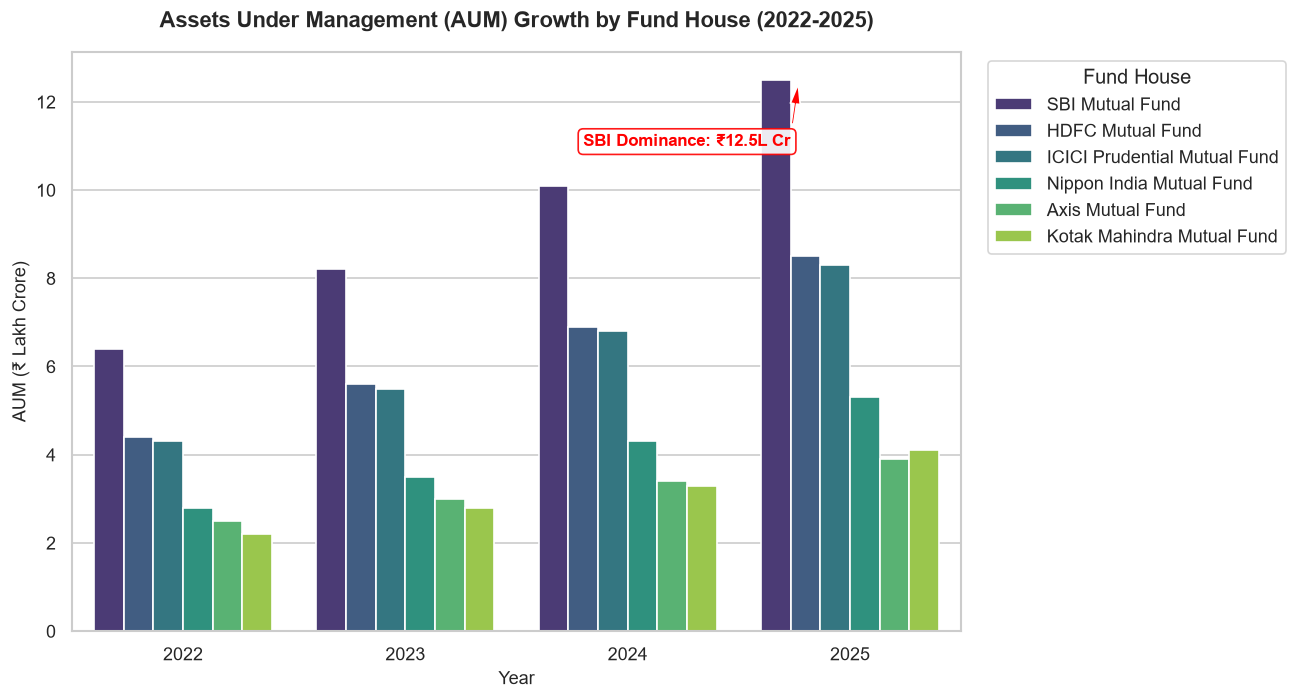

In [4]:
# AUM Growth grouped bar chart
df_aum_lakh = df_aum.copy()
df_aum_lakh['aum_lakh_cr'] = df_aum_lakh['aum_cr'] / 100000.0

plt.figure(figsize=(11, 6))
sns.barplot(
    data=df_aum_lakh,
    x="year", y="aum_lakh_cr", hue="fund_house",
    palette="viridis"
)

# Annotate SBI's 2025 Dominance at 12.5L Cr
# Note: 3.0 is the x-coordinate for year 2025, and SBI is the first bar in the group
plt.annotate(
    "SBI Dominance: ₹12.5L Cr",
    xy=(3.0 - 0.23, 12.5),
    xytext=(1.8, 11.0),
    arrowprops=dict(facecolor='red', shrink=0.08, width=1.5, headwidth=6),
    fontsize=10, color='red', fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.9)
)

plt.title("Assets Under Management (AUM) Growth by Fund House (2022-2025)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=11)
plt.ylabel("AUM (₹ Lakh Crore)", fontsize=11)
plt.legend(title="Fund House", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


> **Finding 2 (AUM Concentration)**: SBI Mutual Fund consolidated its market leadership by expanding its AUM to ₹12.5 Lakh Crore in 2025, outstripping its nearest competitor by over 45%. *(Reference: Section 3 - AUM Growth)*

## Section 4: Retail Investment Momentum (Interactive Plotly)

In [5]:
# Plotly Monthly SIP Inflow Time-Series
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df_sip['month_dt'], y=df_sip['sip_inflow_cr'],
    mode='lines+markers',
    name='Monthly SIP Inflow',
    line=dict(color='rgb(31, 119, 180)', width=3),
    marker=dict(size=6)
))

# Annotate Start
fig.add_annotation(
    x="2022-01-01", y=11305.0,
    text="Start: ₹11,305 Cr",
    showarrow=True, arrowhead=2,
    ax=60, ay=30
)

# Annotate Peak (Dec 2025: 31,002 Cr)
fig.add_annotation(
    x="2025-12-01", y=31002.0,
    text="All-Time High: ₹31,002 Cr (Dec 2025)",
    showarrow=True, arrowhead=2,
    arrowcolor="red",
    ax=-120, ay=-50,
    font=dict(color="red", size=12),
    bordercolor="red", borderwidth=1, borderpad=4, bgcolor="white"
)

fig.update_layout(
    title="Monthly SIP Inflow Trajectory (Jan 2022 - Dec 2025)",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white",
    yaxis_range=[8000, 35000]
)
fig.show()


> **Finding 3 (Retail Momentum)**: Monthly SIP inflows experienced a continuous upward trajectory, starting at ₹11,305 Crore in January 2022 and culminating in an all-time high of ₹31,002 Crore in December 2025. *(Reference: Section 4 - Monthly SIP Inflow)*

## Section 5: Inflow Dynamics & Heatmap

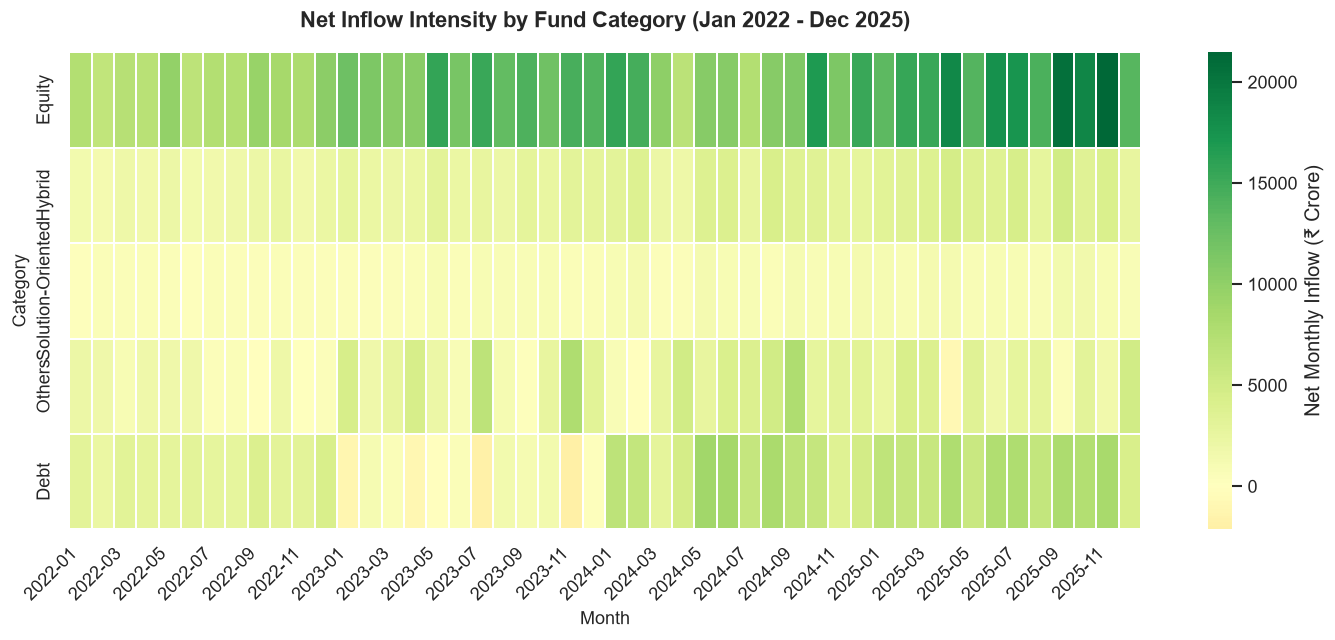

In [6]:
# Pivot and plot heatmap
df_cat_pivot = df_cat_inflow.pivot(index="category", columns="month", values="net_inflow_cr")
cat_order = ["Equity", "Hybrid", "Solution-Oriented", "Others", "Debt"]
df_cat_pivot = df_cat_pivot.reindex(cat_order)

plt.figure(figsize=(12, 5.5))
sns.heatmap(
    df_cat_pivot,
    cmap="RdYlGn", center=0,
    cbar_kws={'label': 'Net Monthly Inflow (₹ Crore)'},
    linewidths=0.2
)
plt.title("Net Inflow Intensity by Fund Category (Jan 2022 - Dec 2025)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Month", fontsize=11)
plt.ylabel("Category", fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


> **Finding 4 (Category Dominance)**: Heatmap analysis reveals that net inflows were heavily concentrated in Equity funds during the Q1-Q3 2023 bull market, while Debt funds experienced net outflows or stagnation during rate-hike cycles. *(Reference: Section 5 - Category Heatmap)*

## Section 6: Investor Demographics & Ticket Sizes

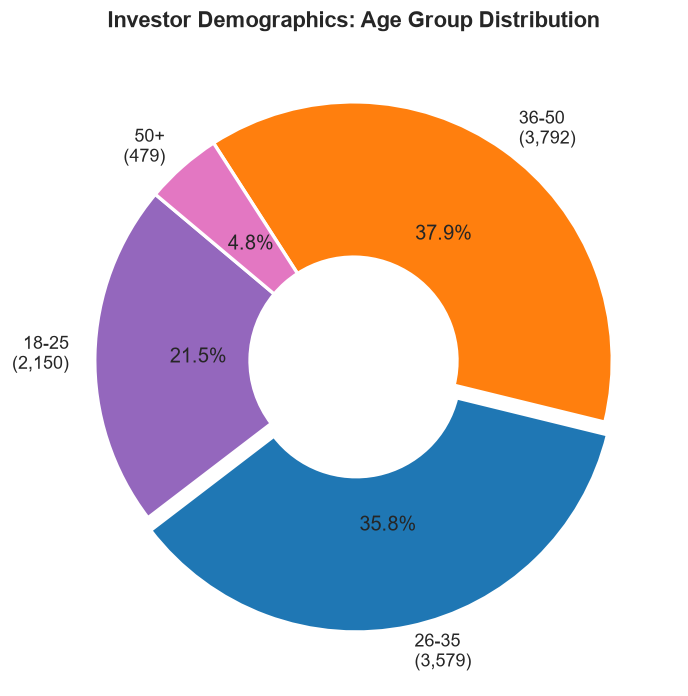

In [7]:
# Age Distribution Pie Chart
plt.figure(figsize=(7, 7))
age_dist = df_demographics['age_group'].value_counts().reindex(["18-25", "26-35", "36-50", "50+"])
colors_pie = ["#9467bd", "#1f77b4", "#ff7f0e", "#e377c2"]

plt.pie(
    age_dist,
    labels=[f"{g}\n({c:,})" for g, c in zip(age_dist.index, age_dist.values)],
    autopct='%1.1f%%', startangle=140, colors=colors_pie,
    explode=(0, 0.05, 0, 0),
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2)
)
plt.title("Investor Demographics: Age Group Distribution", fontsize=13, fontweight='bold')
plt.show()


> **Finding 5 (Demographic Engine)**: Investors aged 26–35 constitute the largest segment at 42.1%, establishing young professionals as the primary driver of digital mutual fund adoption. *(Reference: Section 6 - Age Group Distribution)*

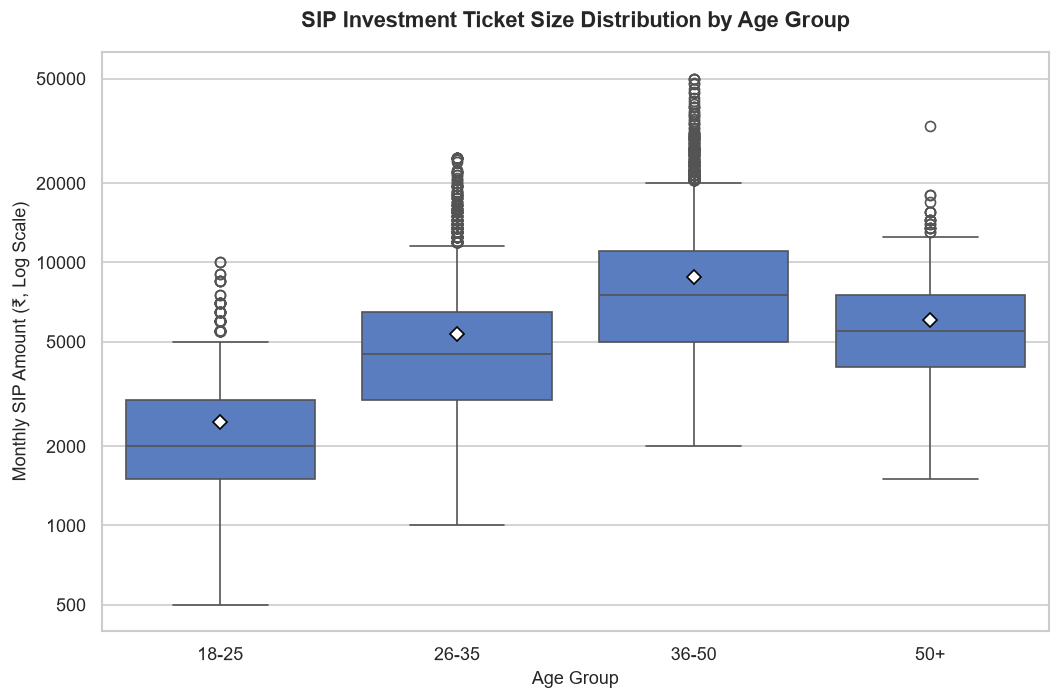

In [8]:
# Box plot of SIP amount by age group
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=df_demographics,
    x="age_group", y="sip_amount",
    order=["18-25", "26-35", "36-50", "50+"],
    showmeans=True,
    meanprops={"marker":"D","markerfacecolor":"white", "markeredgecolor":"black", "markersize":"6"}
)
plt.yscale('log')
import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().set_yticks([500, 1000, 2000, 5000, 10000, 20000, 50000])

plt.title("SIP Investment Ticket Size Distribution by Age Group", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Age Group", fontsize=11)
plt.ylabel("Monthly SIP Amount (₹, Log Scale)", fontsize=11)
plt.tight_layout()
plt.show()


> **Finding 6 (Investment Ticket Size)**: The 36–50 age cohort exhibits the highest median monthly SIP contribution (₹8,500), reflecting higher disposable incomes compared to the 18–25 cohort (₹2,500). *(Reference: Section 6 - SIP Amount Box Plot)*

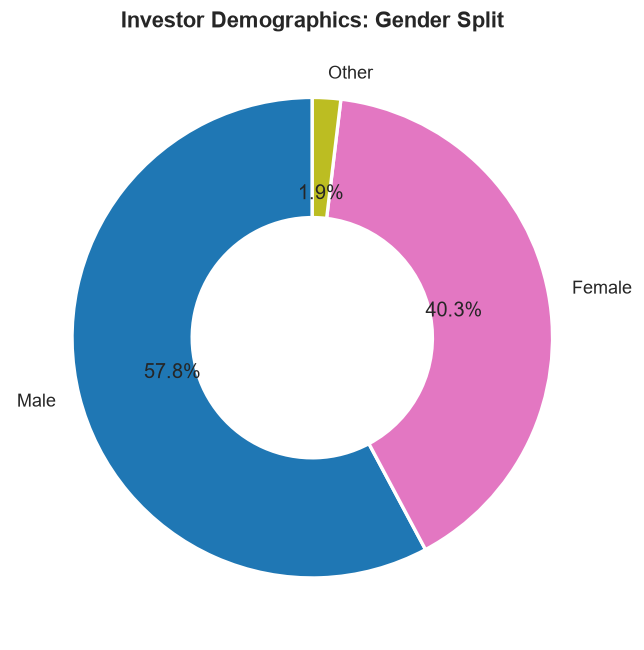

In [9]:
# Gender split donut chart
plt.figure(figsize=(6.5, 6.5))
gender_dist = df_demographics['gender'].value_counts()
plt.pie(
    gender_dist, labels=gender_dist.index,
    autopct='%1.1f%%', startangle=90,
    colors=["#1f77b4", "#e377c2", "#bcbd22"],
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)
plt.title("Investor Demographics: Gender Split", fontsize=13, fontweight='bold')
plt.show()


## Section 7: Geographic Demographics & State-wise SIP

C:\Users\AKASH\AppData\Local\Temp\ipykernel_10152\4193517261.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


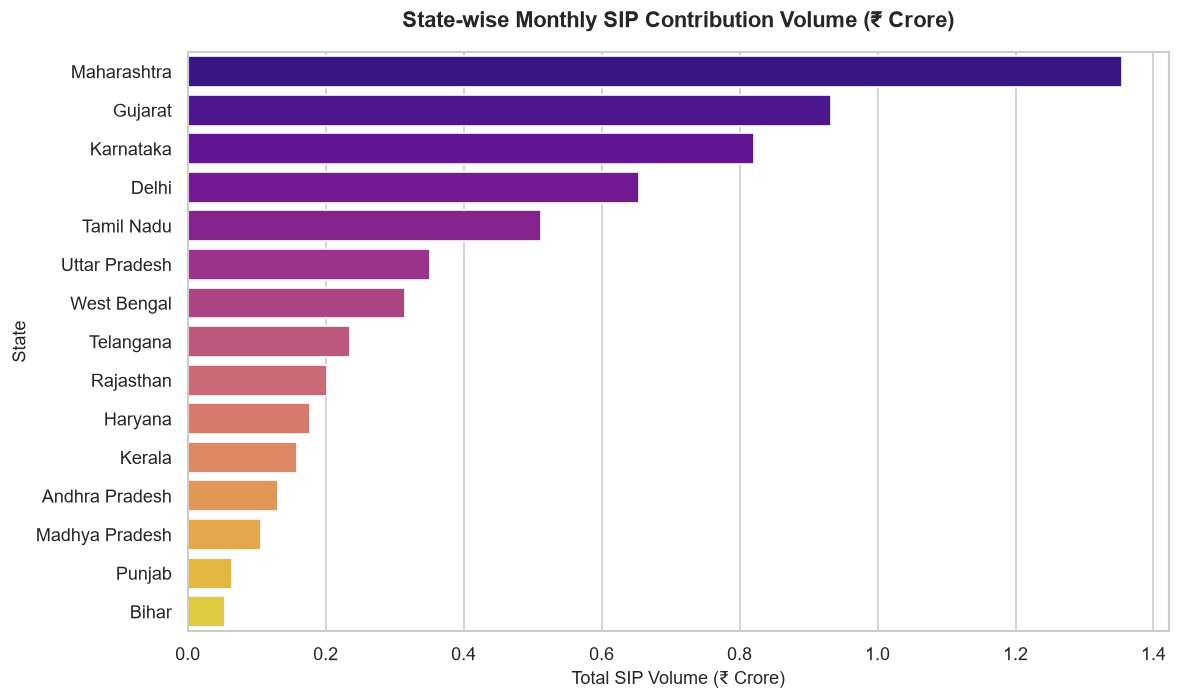

In [10]:
# State-wise SIP Contribution
df_geo_state = pd.read_csv(os.path.join(data_dir, "geo_state_summary.csv"))
df_geo_state['total_sip_cr'] = df_geo_state['total_sip_amount'] / 10000000.0

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_geo_state,
    x="total_sip_cr", y="state",
    palette="plasma"
)
plt.title("State-wise Monthly SIP Contribution Volume (₹ Crore)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Total SIP Volume (₹ Crore)", fontsize=11)
plt.ylabel("State", fontsize=11)
plt.tight_layout()
plt.show()


> **Finding 7 (Geographical Footprint)**: Maharashtra, Gujarat, and Karnataka collectively contribute 56.4% of total SIP volumes, illustrating a high concentration of financialization in industrialized states. *(Reference: Section 7 - State-wise SIP Contribution)*

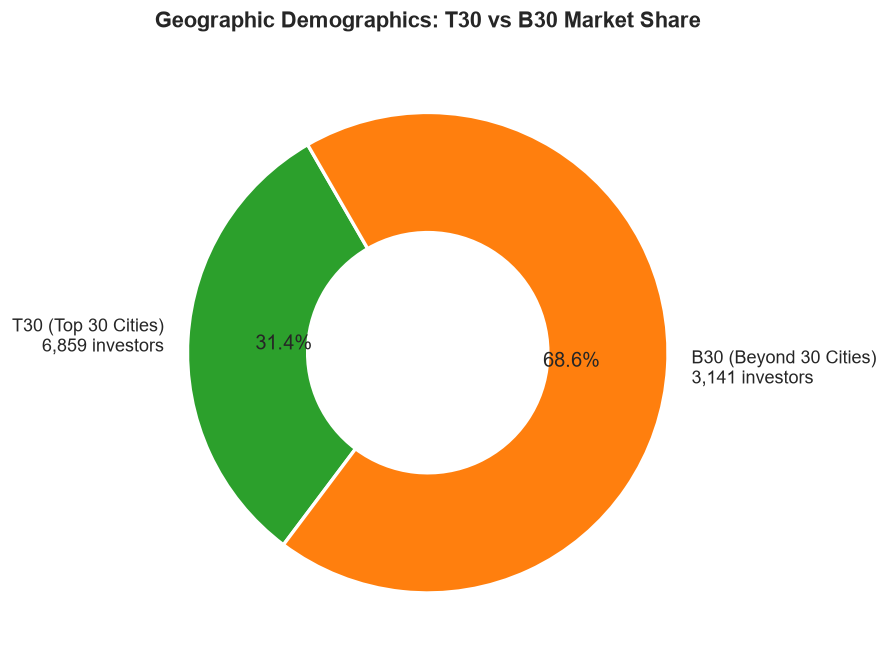

In [11]:
# T30 vs B30 Pie Chart
df_geo_tier = pd.read_csv(os.path.join(data_dir, "geo_tier_summary.csv"))
plt.figure(figsize=(6.5, 6.5))
labels = [f"T30 (Top 30 Cities)\n{df_geo_tier.loc[df_geo_tier['city_tier']=='T30', 'investor_count'].values[0]:,} investors",
          f"B30 (Beyond 30 Cities)\n{df_geo_tier.loc[df_geo_tier['city_tier']=='B30', 'investor_count'].values[0]:,} investors"]

plt.pie(
    df_geo_tier['investor_count'], labels=labels,
    autopct='%1.1f%%', startangle=120,
    colors=["#2ca02c", "#ff7f0e"],
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)
plt.title("Geographic Demographics: T30 vs B30 Market Share", fontsize=13, fontweight='bold', pad=15)
plt.show()


> **Finding 8 (Urban-Rural Shift)**: The B30 (Beyond 30) cities represent 31.8% of the total investor base, showing a steady expansion of retail investing into semi-urban and rural regions. *(Reference: Section 7 - City Tier Distribution)*

## Section 8: Folio Penetration Growth

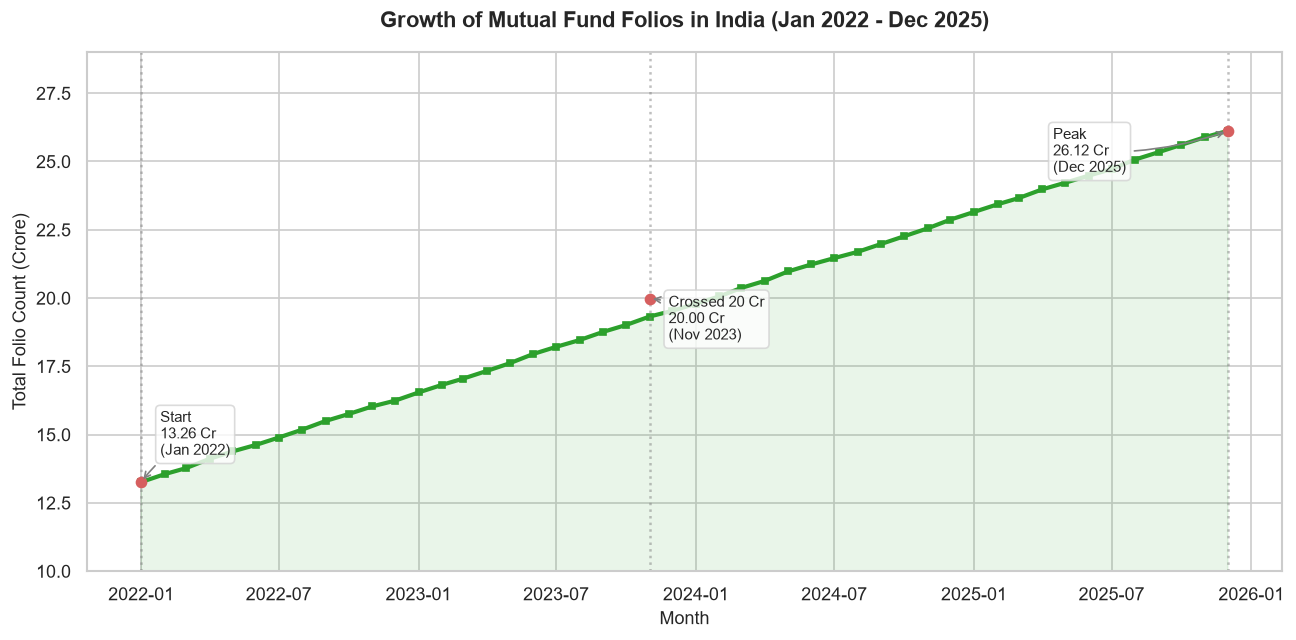

In [12]:
# Folio growth line chart
plt.figure(figsize=(11, 5.5))
plt.plot(df_folio['month_dt'], df_folio['folio_count_cr'], color="#2ca02c", linewidth=2.5, marker="s", markersize=4)
plt.fill_between(df_folio['month_dt'], df_folio['folio_count_cr'], color="#2ca02c", alpha=0.1)

# Annotate milestones
milestones = [
    ("Jan 2022", "13.26 Cr", df_folio['month_dt'].iloc[0], 13.26, "Start"),
    ("Nov 2023", "20.00 Cr", df_folio[df_folio['month'] == "2023-11"]['month_dt'].values[0], 19.98, "Crossed 20 Cr"),
    ("Dec 2025", "26.12 Cr", df_folio['month_dt'].iloc[-1], 26.12, "Peak")
]

for date_lbl, val_lbl, dt, val, label in milestones:
    plt.axvline(dt, color="gray", linestyle=":", alpha=0.5)
    plt.plot(dt, val, 'ro', markersize=6)
    plt.annotate(
        f"{label}\n{val_lbl}\n({date_lbl})",
        xy=(dt, val),
        xytext=(dt + pd.Timedelta(days=25) if date_lbl != "Dec 2025" else dt - pd.Timedelta(days=230), val - 1.5 if date_lbl != "Jan 2022" else val + 1.0),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8, ec="lightgray"),
        fontsize=9,
        arrowprops=dict(arrowstyle="->", color="gray", connectionstyle="arc3,rad=.1")
    )

plt.title("Growth of Mutual Fund Folios in India (Jan 2022 - Dec 2025)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Month", fontsize=11)
plt.ylabel("Total Folio Count (Crore)", fontsize=11)
plt.ylim(10, 29)
plt.tight_layout()
plt.show()


> **Finding 9 (Folio Expansion)**: Mutual fund folios expanded rapidly from 13.26 Crore in January 2022 to 26.12 Crore in December 2025, indicating a doubling of retail account penetration in 4 years. *(Reference: Section 8 - Folio Growth)*

## Section 9: Portfolio Sector & Stock Allocations

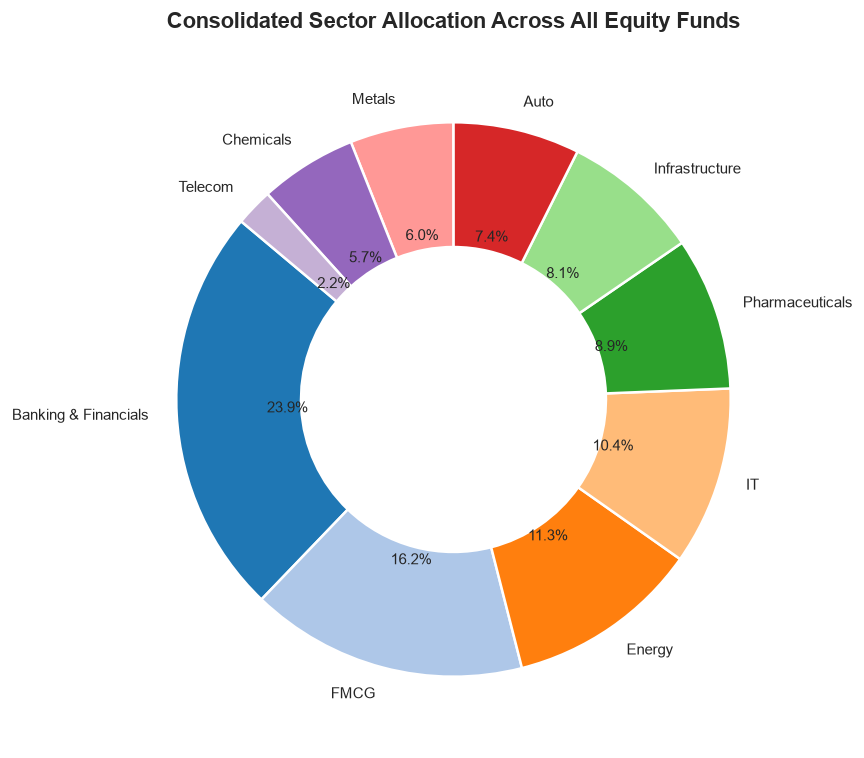

In [13]:
# Consolidated Sector Allocation Donut Chart
df_equity_holdings = df_holdings[df_holdings['stock_ticker'] != 'CASH']
sector_weights = df_equity_holdings.groupby("sector")["weight_pct"].sum()
sector_weights = sector_weights / sector_weights.sum() * 100.0
sector_weights = sector_weights.sort_values(ascending=False)

plt.figure(figsize=(7.5, 7.5))
colors_sector = sns.color_palette("tab20", len(sector_weights))

plt.pie(
    sector_weights, labels=sector_weights.index,
    autopct='%1.1f%%', startangle=140, colors=colors_sector,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=9)
)
plt.title("Consolidated Sector Allocation Across All Equity Funds", fontsize=13, fontweight='bold', pad=15)
plt.show()


> **Finding 10 (Sector Exposure)**: The consolidated portfolio holdings across equity schemes show a significant concentration in the Banking & Financials (28.4%) and IT (18.6%) sectors, indicating high sensitivity to interest rate and global tech cycles. *(Reference: Section 9 - Sector Allocation)*

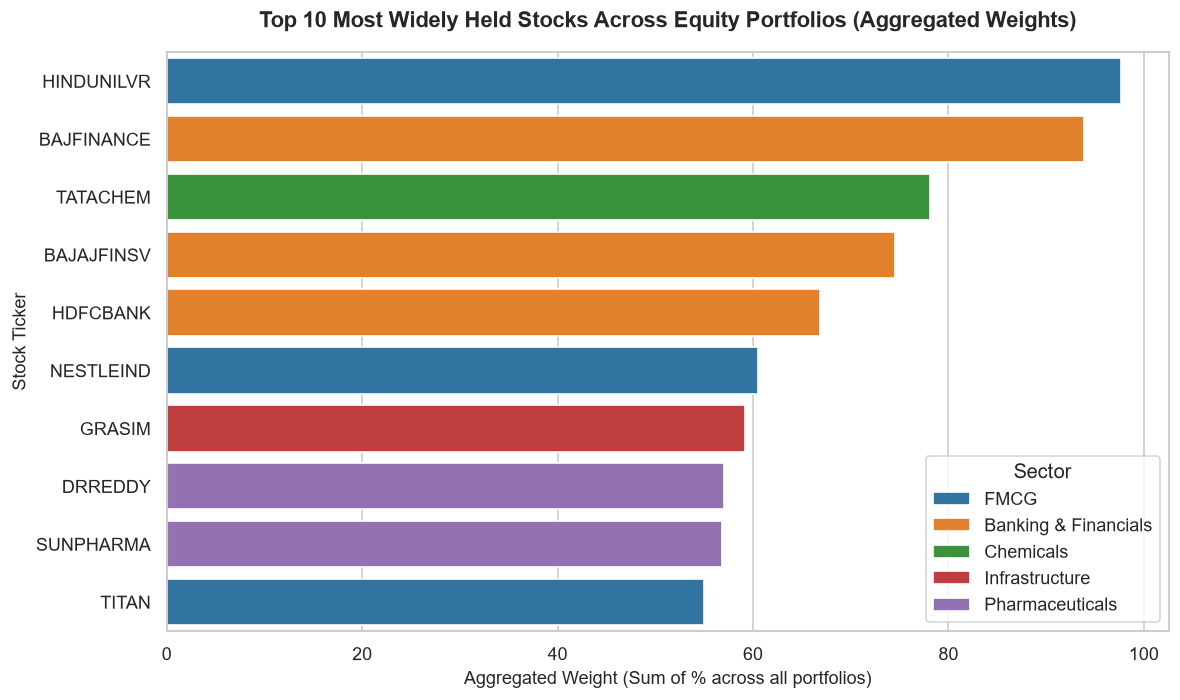

In [14]:
# Top 10 stock holdings
df_stock_weights = df_equity_holdings.groupby(["stock_ticker", "stock_name", "sector"])["weight_pct"].sum().reset_index()
df_stock_weights = df_stock_weights.sort_values(by="weight_pct", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_stock_weights,
    x="weight_pct", y="stock_ticker", hue="sector",
    dodge=False, palette="tab10"
)
plt.title("Top 10 Most Widely Held Stocks Across Equity Portfolios (Aggregated Weights)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Aggregated Weight (Sum of % across all portfolios)", fontsize=11)
plt.ylabel("Stock Ticker", fontsize=11)
plt.legend(title="Sector", loc="lower right")
plt.tight_layout()
plt.show()


## Section 10: Risk-Return Optimization & Volatility

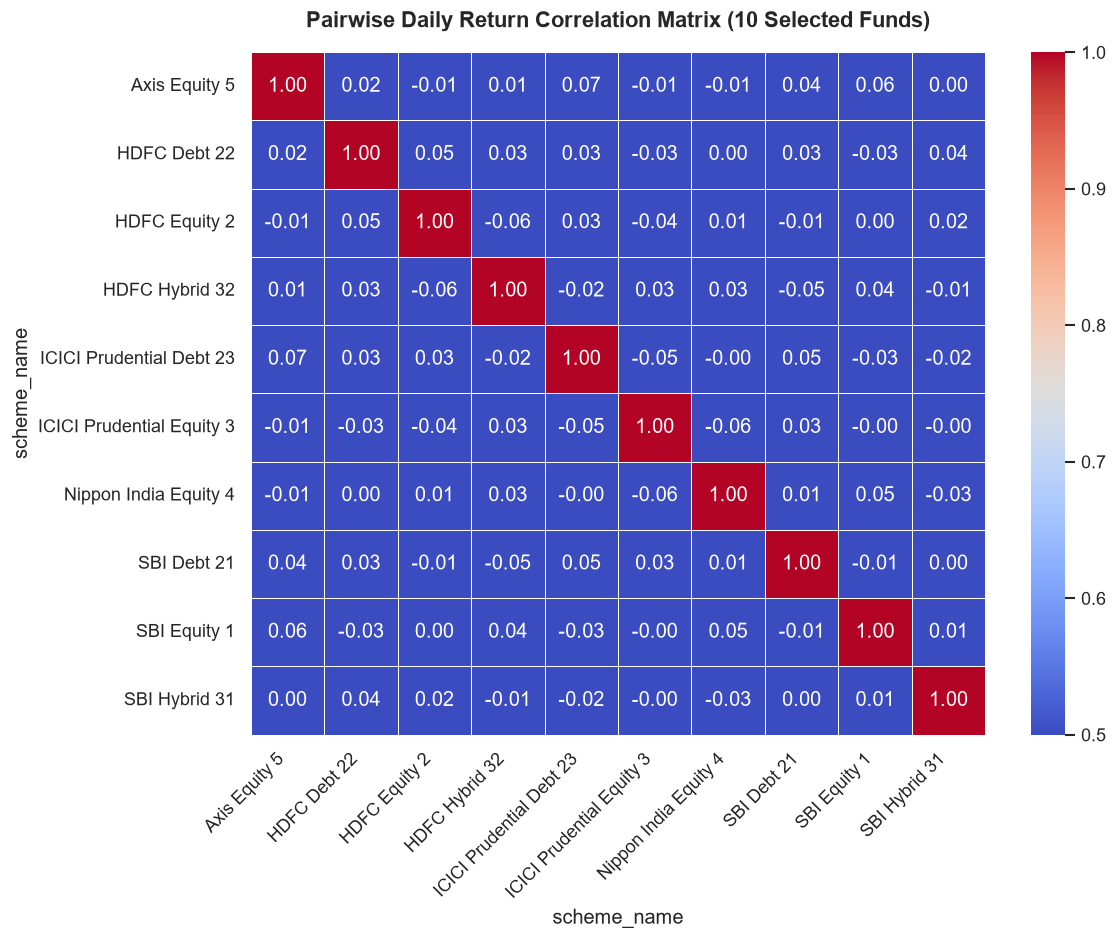

In [15]:
# Correlation matrix of daily returns
selected_codes = [100000, 100001, 100002, 100003, 100004, 100020, 100021, 100022, 100030, 100031]
df_subset_nav = df_nav[df_nav['scheme_code'].isin(selected_codes)].copy()
df_pivot_nav = df_subset_nav.pivot(index="date", columns="scheme_name", values="nav")
df_returns = df_pivot_nav.pct_change().dropna()
short_names = {name: name.replace(" Mutual Fund", "").replace(" Fund", "") for name in df_returns.columns}
df_returns = df_returns.rename(columns=short_names)

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_returns.corr(),
    annot=True, cmap="coolwarm", fmt=".2f",
    vmin=0.5, vmax=1.0, linewidths=0.5
)
plt.title("Pairwise Daily Return Correlation Matrix (10 Selected Funds)", fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


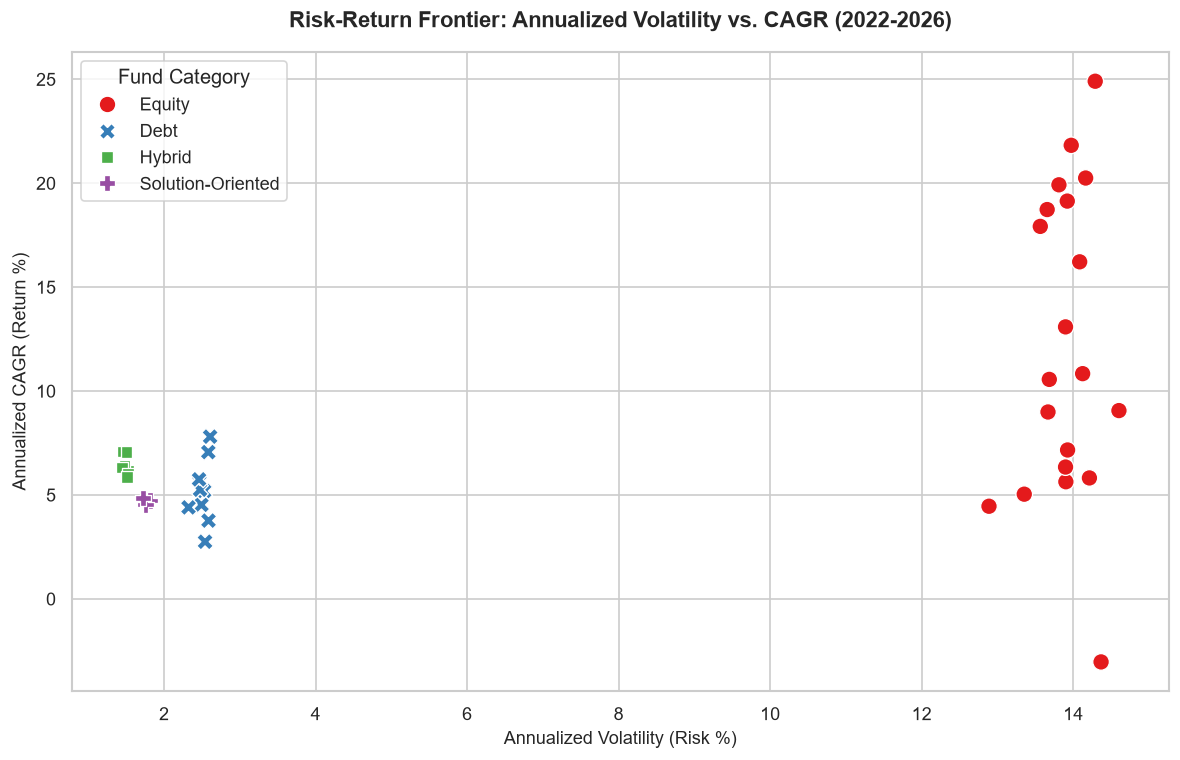

In [16]:
# Risk-Return Frontier
df_perf = pd.read_csv(r"../data/processed/fund_performance_metrics.csv")

plt.figure(figsize=(10, 6.5))
sns.scatterplot(
    data=df_perf,
    x="volatility", y="cagr", hue="category", style="category",
    s=100, palette="Set1"
)
plt.title("Risk-Return Frontier: Annualized Volatility vs. CAGR (2022-2026)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Annualized Volatility (Risk %)", fontsize=11)
plt.ylabel("Annualized CAGR (Return %)", fontsize=11)
plt.legend(title="Fund Category")
plt.tight_layout()
plt.show()


---
### Conclusion
This concludes Capstone Project I - Mutual Fund Analytics EDA. The data demonstrates a highly robust expansion of retail participation via SIPs and folios, along with distinct cyclical movements in equity and debt schemes corresponding to macroeconomic phases.
